<a href="https://colab.research.google.com/github/hig3r/colab-probstat/blob/main/%E9%80%A3%E7%B6%9A%E5%9E%8B%E7%A2%BA%E7%8E%87%E5%A4%89%E6%95%B0_2%E6%AC%A1%E9%96%A2%E6%95%B0%E3%81%A7%E6%9B%B8%E3%81%91%E3%82%8B%E5%88%86%E5%B8%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 準備



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy import stats
from scipy import integrate # 数値積分
%matplotlib inline

In [ ]:
np.random.seed(1637)

# 連続型確率変数

scipy.stats で確率密度関数を自由に与えて, 連続型確率変数を扱うのは少したいへん(自分でクラスを継承して定義する必要がある).

有名な分布は定義済みだが，ここで扱う分布は有名なものではないので，直に数値積分をして考える．integrate=積分，quadrature=数値的（台形公式とか）



## 2次関数で書ける分布

次の確率密度関数$f(x)$で定まる分布を，授業内ではQ$(0,1^2)$とよぶ．世の中ではEpanechnikovカーネルとも呼ばれる．

$$ f(z)=
\begin{cases}
-\frac{3}{20\sqrt{5}}(z^2-5) & (|z|\leq \sqrt{5})\\
0 & (\text{他})\\
\end{cases}
$$
次のようにも書ける．
$$
f(z)=\max(0,\frac{3}{4\sqrt{5}}(1-\frac{z^2}{5}))
$$

In [ ]:
def f0(x):
  return 3/4/np.sqrt(5)*(1-(x**2)/5)
def f(x):
  condition = np.abs(x) <= np.sqrt(5)
  return np.where(condition, 3/4/np.sqrt(5)*(1-(x**2)/5), 0)

## 確率密度関数 $f(z)$ のグラフ

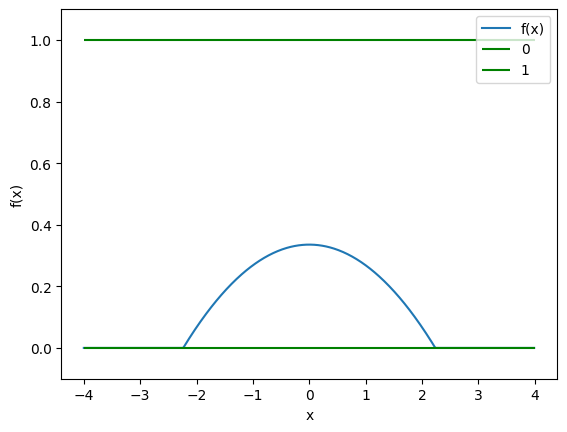

In [ ]:
x=np.arange(-4,4,0.01)
fig, ax = plt.subplots(1, 1)
ax.plot(x,f(x))
ax.hlines(1,-4,4,color="green")
ax.hlines(0,-4,4,color="green")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_ylim(-0.1,1.1)
ax.legend(["f(x)", "0","1"])
fig.show()

## 一部のモーメント，母平均値・母分散・母標準偏差の計算

In [ ]:
integrate.quad(f,-np.sqrt(5),+np.sqrt(5)) # E[X^0]は1になっている

(1.0000000000000002, 1.1102230246251569e-14)

In [ ]:
integrate.quad(lambda x: x* f(x), -np.sqrt(5), +np.sqrt(5)) # 母平均値 E [𝑋1]  は，奇関数の，原点に関して対称な領域での定積分なので0になる

(0.0, 9.239933067273834e-15)

母平均値 E$[Z^1]$ は，奇関数の，原点に関して対称な領域での定積分なので0になる．

In [ ]:
integrate.quad(lambda x: x**2 * f(x), -np.sqrt(5), +np.sqrt(5)) # E[X^2]=Var(X) は1

(1.0000000000000002, 1.1102230246251569e-14)

## 累積分布関数$F(z)$
$$
F(z)=
\begin{cases}
0 & (z\lt -\sqrt{5})\\
-\frac{3}{20\sqrt{5}}(\frac{z^3}{3}-5z+\frac{2\sqrt{5}}{3})  & (-\sqrt{5} \leq z\leq \sqrt{5})\\
1 & (+\sqrt{5}\lt z)
\end{cases}
$$

In [ ]:
def F0(x):
  return 3/(4*np.sqrt(5))*(x-x**3/15+2/3*np.sqrt(5))
def F(x):
  cond1 = x <= -np.sqrt(5)
  cond2 = x <= np.sqrt(5)
  # Use np.where for vectorized application of the conditions
  return np.where(cond1, 0, np.where(cond2, F0(x), 1))

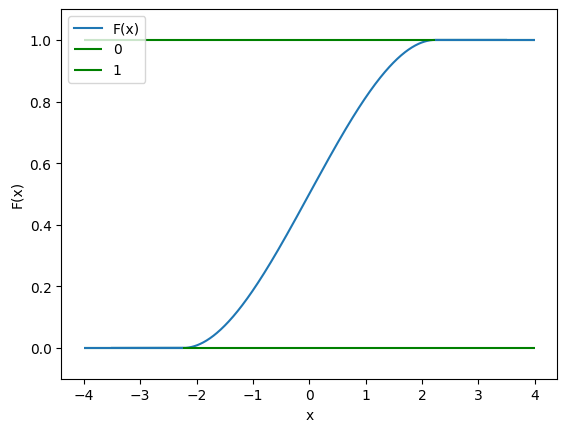

In [ ]:
x=np.arange(-3.5,3.5,0.01) # Restricted x-axis range
fig, ax = plt.subplots(1, 1)
ax.plot(x,F(x)) # Use the vectorized F(x) function
ax.hlines(1,-4,4,color='green')
ax.hlines(0,-4,4,color='green')
ax.hlines(1,2.236,4)
ax.hlines(0,-4,-2.236)
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.set_ylim(-0.1,1.1)
ax.legend(["F(x)", "0","1"])
fig.show()

### 区間の確率の計算
$ P(x_1 \lt X \leq x_2)=F(x_2)-F(x_1)$

In [ ]:
F(2)-F(1)

np.float64(0.17888543819998304)

## 分位数関数 $F^{-1}(p)$

$p=F(x)$ を$x\in[0,1]$について解く．3次方程式の解の公式を使って，



$$ x=F^{-1}(p)=2\sqrt{5}\cos(\frac13\arccos(1-2p)-\frac23\pi)$$

In [ ]:
def Finv(p):
  return 2*np.sqrt(5)*np.cos(1/3*np.arccos(1-2*p)-2/3*np.pi)

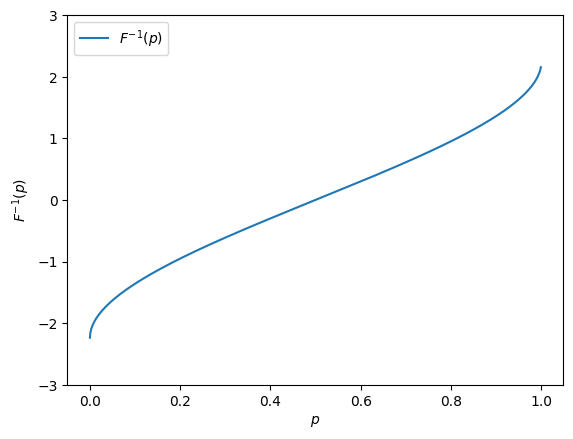

In [ ]:
x=np.arange(0,1,0.001)
fig, ax = plt.subplots(1, 1)
ax.plot(x,Finv(x))
ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$F^{-1}(p)$")
ax.set_ylim(-3,3)
ax.legend(["$F^{-1}(p)$"], loc='upper left')
fig.show()

### 分位数の計算

In [ ]:
Finv(0.9)

np.float64(1.3604232849890499)

# 連続型確率変数の1次式による変換
$X=aZ+b$, $Z=\frac{X-b}{a}$

例
$Z\sim \mathrm{Q}(0,1^2)$
$X=2Z+3$
ならば
$X\sim \mathrm{Q}(3,2^2)$


## 確率密度関数 $f_x(x)$

一般に，
$$f_x(x)=\frac{1}{a}f_z(\frac{x-b}{a})$$


この分布の場合，
$$
f_x(x)=
\begin{cases}
-\frac{3}{20\sqrt{5}a}(\frac{(x-b)^2}{a^2}-5) & (|\frac{x-b}{a}|\leq \sqrt{5})\\
0 & (\text{他})
\end{cases}
=
\begin{cases}
\frac{3}{4\sqrt{5}a}(1-\frac{(x-b)^2}{5a^2}) & (b-\sqrt{5}a\leq x \leq b+\sqrt{5}a)\\
0 & (\text{他})
\end{cases}
$$


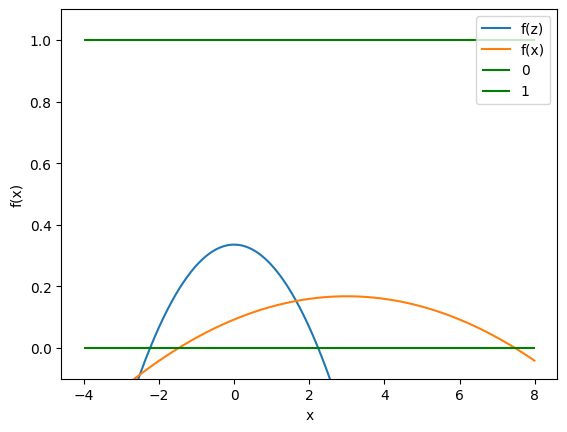

In [ ]:
x=np.arange(-4,8,0.01)
fig, ax = plt.subplots(1, 1)
ax.plot(x,f0(x))
ax.plot(x,f0((x-3)/2)/2)
ax.hlines(1,-4,8,color="green")
ax.hlines(0,-4,8,color="green")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_ylim(-0.1,1.1)
ax.legend(["f(z)", "f(x)","0","1"])
fig.show()

## 累積分布関数$F(x)$
$$
F(\frac{x-b}{a})=
\begin{cases}
0 & (x\lt -a\sqrt{5}+b)\\
\frac{3}{4\sqrt{5}}(\frac{x-b}{a}-\frac{1}{15}(\frac{(x-b)}{a})^3+\tfrac23\sqrt{5})  & (-a\sqrt{5}+b \leq x\leq a\sqrt{5}+b)\\
1 & (+a\sqrt{5}+b\lt x)
\end{cases}
$$

In [ ]:
def F0(x):
  return 3/(4*np.sqrt(5))*(x-x**3/15+2/3*np.sqrt(5))
def F(x):
  if x<=-np.sqrt(5) :
    return 0
  elif x<=np.sqrt(5):
    return F0(x)
  else:
    return 1

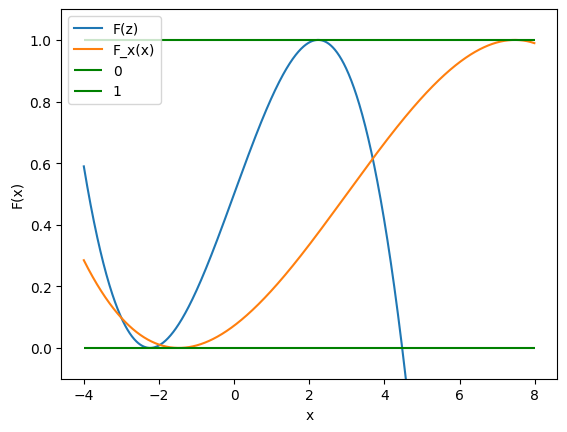

In [ ]:
x=np.arange(-4,8,0.01)
fig, ax = plt.subplots(1, 1)
ax.plot(x,F0(x))
ax.plot(x,F0((x-3)/2))
ax.hlines(1,-4,8,color="green")
ax.hlines(0,-4,8,color="green")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.set_ylim(-0.1,1.1)
ax.legend(["F(z)", "F_x(x)","0","1"])
fig.show()

# 連続型確率変数の標準化
$Z=\frac{X-\mu}{\sigma}$ or $X=\sigma Z+\mu$.

$\mu=b=\mathrm{E}[X], \sigma=a=\sqrt{\mathrm{Var}(X)}$.

例
$X\sim \mathrm{Q}(3,2^2)$
ならば $\mu=3, \sigma=2$.

$Z=\frac{X-3}{2}\sim \mathrm{Q}(0,1^2)$


$P(1 \lt X \leq 4)=P(\frac{1-3}{2} \lt Z \leq \frac{4-3}{2})=F_z(\frac{4-3}{2})-F_z(\frac{1-3}{2})$